In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))
import numpy as np
import matplotlib.pyplot as plt

import utils.helpers as hlp 
from utils.evaluation import AccuracyEvaluator
from samplers.dpsgld import BayesianRegressionDPSGLD
from samplers.mysgld import BayesianRegressionMYSGLD

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Math

## Sampling with the Wisconsin Breast Cancer data  
### Load and Preprocess the data

In [2]:
seed=42
X, y = load_breast_cancer(return_X_y=True, as_frame=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=seed, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_train = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test = np.c_[np.ones((X_test.shape[0], 1)), X_test]
y_train = np.asarray(y_train, dtype=int)
y_test = np.asarray(y_test, dtype=int)

print(f"Training data contains {X_train.shape[0]} observations\n" 
      f"Test data contains {X_test.shape[0]} observations\n"
      f"Dimension: {X_train.shape[1]}")

Training data contains 455 observations
Test data contains 114 observations
Dimension: 31


In [3]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train, y_train)
beta_hat = clf.coef_.flatten()
lp = 2 
s = 0.8 * np.linalg.norm(beta_hat, ord=lp)
display(
    Math(
        rf'\|\hat{{\beta}}\|_{lp}={np.linalg.norm(beta_hat, ord=lp):.4f}, '
        rf'\quad s={s:.4f}')
)

<IPython.core.display.Math object>

### Sample the posterior

In [6]:
def run_sampling(
    X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,
    n_samples=500, batch=10, n_iters=1000, n_agents=5, eta=5e-4,
    gamma=1e-3, s=s, lp=lp, type='logistic', seed=seed,
    nets=("fcn", "cn", "sn", "fdn"),
    late_window=100
):
    """
    Visualize DPSGLD performance across network topologies.

    Top row:
        Accuracy of one selected agent under DPSGLD.
    Bottom row:
        Accuracy of the network mean under DPSGLD.

    A centralized MYSGLD reference is shown as a dashed black line.
    The main focus is DPSGLD behavior under different networks
    """
    fig, axes = plt.subplots(2, 4, figsize=(32, 16), sharex=True, sharey=True)
    network_names = ["Fully Connected", "Circular", "Star", "Disconnected"]

    # Centralized reference (computed once)
    mysgld_sampling = BayesianRegressionMYSGLD(
        X=X_train, y=y_train, s=s, lp=lp, n_samples=n_samples,
        n_iters=n_iters, eta=eta, gamma=gamma*n_agents, type=type,
        seed=seed, batch=batch
    )
    mysgld_chain = mysgld_sampling.sample_parameters()
    mysgld_evaluator = AccuracyEvaluator(mysgld_chain)
    mysgld_acc, mysgld_std = mysgld_evaluator.compute_accuracy(X_test, y_test)

    # Late-stage centralized reference level
    mysgld_late_mean = np.mean(mysgld_acc[-late_window:])

    summary_stats = []

    for i, (net, name) in enumerate(zip(nets, network_names)):
        ax_top = axes[0, i]
        ax_bottom = axes[1, i]

        dpsgld_sampling = BayesianRegressionDPSGLD(
            X=X_train, y=y_train, s=s, lp=lp, n_samples=n_samples,
            n_agents=n_agents, n_iters=n_iters, eta=eta, gamma=gamma,
            type=type, net=net, batch=batch, seed=seed
        )
        history_all, beta_mean_all = dpsgld_sampling.sample_parameters()

        # Selected agent evaluation
        dpsgld_agent_evaluator = AccuracyEvaluator(history_all)
        dpsgld_agent_acc, dpsgld_agent_std = dpsgld_agent_evaluator.compute_accuracy(
            X_test, y_test
        )
        agent = dpsgld_agent_evaluator.get_selected_agent()

        # Network mean evaluation
        dpsgld_mean_evaluator = AccuracyEvaluator(beta_mean_all)
        dpsgld_mean_acc, dpsgld_mean_std = dpsgld_mean_evaluator.compute_accuracy(
            X=X_test, y=y_test
        )

        # ----- Top row: selected agent -----
        ax_top.plot(
            dpsgld_agent_acc, color="green", linewidth=3,
            label="DE-PSGLD selected agent" if i == 0 else None
        )
        ax_top.fill_between(
            range(len(dpsgld_agent_acc)),
            dpsgld_agent_acc - dpsgld_agent_std,
            dpsgld_agent_acc + dpsgld_agent_std,
            color="green", alpha=0.22
        )
        ax_top.plot(
            mysgld_acc, "k--", linewidth=2, alpha=0.9,
            label="PSGLD reference" if i == 0 else None
        )
        ax_top.axhline(
            mysgld_late_mean, color="black", linestyle=":", linewidth=1.8, alpha=0.8,
            label=f"PSGLD late mean ({late_window})" if i == 0 else None
        )
        ax_top.set_title(f"{name}\nSelected Agent {agent+1}", fontsize=26)
        ax_top.set_xlabel("Iteration", fontsize=24)
        ax_top.set_ylabel("Accuracy", fontsize=24)
        ax_top.tick_params(axis="both", labelsize=20)

        # ----- Bottom row: network mean -----
        ax_bottom.plot(
            dpsgld_mean_acc, color="blue", linewidth=3,
            label="DE-PSGLD network mean" if i == 0 else None
        )
        ax_bottom.fill_between(
            range(len(dpsgld_mean_acc)),
            dpsgld_mean_acc - dpsgld_mean_std,
            dpsgld_mean_acc + dpsgld_mean_std,
            color="blue", alpha=0.22
        )
        ax_bottom.plot(
            mysgld_acc, "k--", linewidth=2, alpha=0.9
        )
        ax_bottom.axhline(
            mysgld_late_mean, color="black", linestyle=":", linewidth=1.8, alpha=0.8
        )
        ax_bottom.set_title(f"{name}\nNetwork Mean", fontsize=26)
        ax_bottom.set_xlabel("Iteration", fontsize=24)
        ax_bottom.set_ylabel("Accuracy", fontsize=24)
        ax_bottom.tick_params(axis="both", labelsize=20)

        # Store summary
        summary_stats.append({
            "network": name,
            "selected_agent": agent+1,
            "agent_late_mean": np.mean(dpsgld_agent_acc[-late_window:]),
            "agent_late_std": np.std(dpsgld_agent_acc[-late_window:]),
            "mean_late_mean": np.mean(dpsgld_mean_acc[-late_window:]),
            "mean_late_std": np.std(dpsgld_mean_acc[-late_window:]),
            "mysgld_late_mean": mysgld_late_mean,
            "mysgld_late_std": np.std(mysgld_acc[-late_window:])
        })

    # Shared styling
    for ax in axes.ravel():
        ax.set_ylim(0.25, 0.95)
        ax.grid(alpha=0.2)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=18,
                   frameon=True, bbox_to_anchor=(0.5, 1.03))

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    print(f"\nLate-stage summary over last {late_window} iterations:\n")
    for row in summary_stats:
        print(
            f"{row['network']:<18} | "
            f"Agent {row['selected_agent']:>2} mean: {row['agent_late_mean']:.4f} "
            f"(std {row['agent_late_std']:.4f}) | "
            f"Network mean: {row['mean_late_mean']:.4f} "
            f"(std {row['mean_late_std']:.4f}) | "
            f"MYSGLD ref: {row['mysgld_late_mean']:.4f} "
            f"(std {row['mysgld_late_std']:.4f})"
        )

100%|██████████| 1000/1000 [03:21<00:00,  4.96it/s]


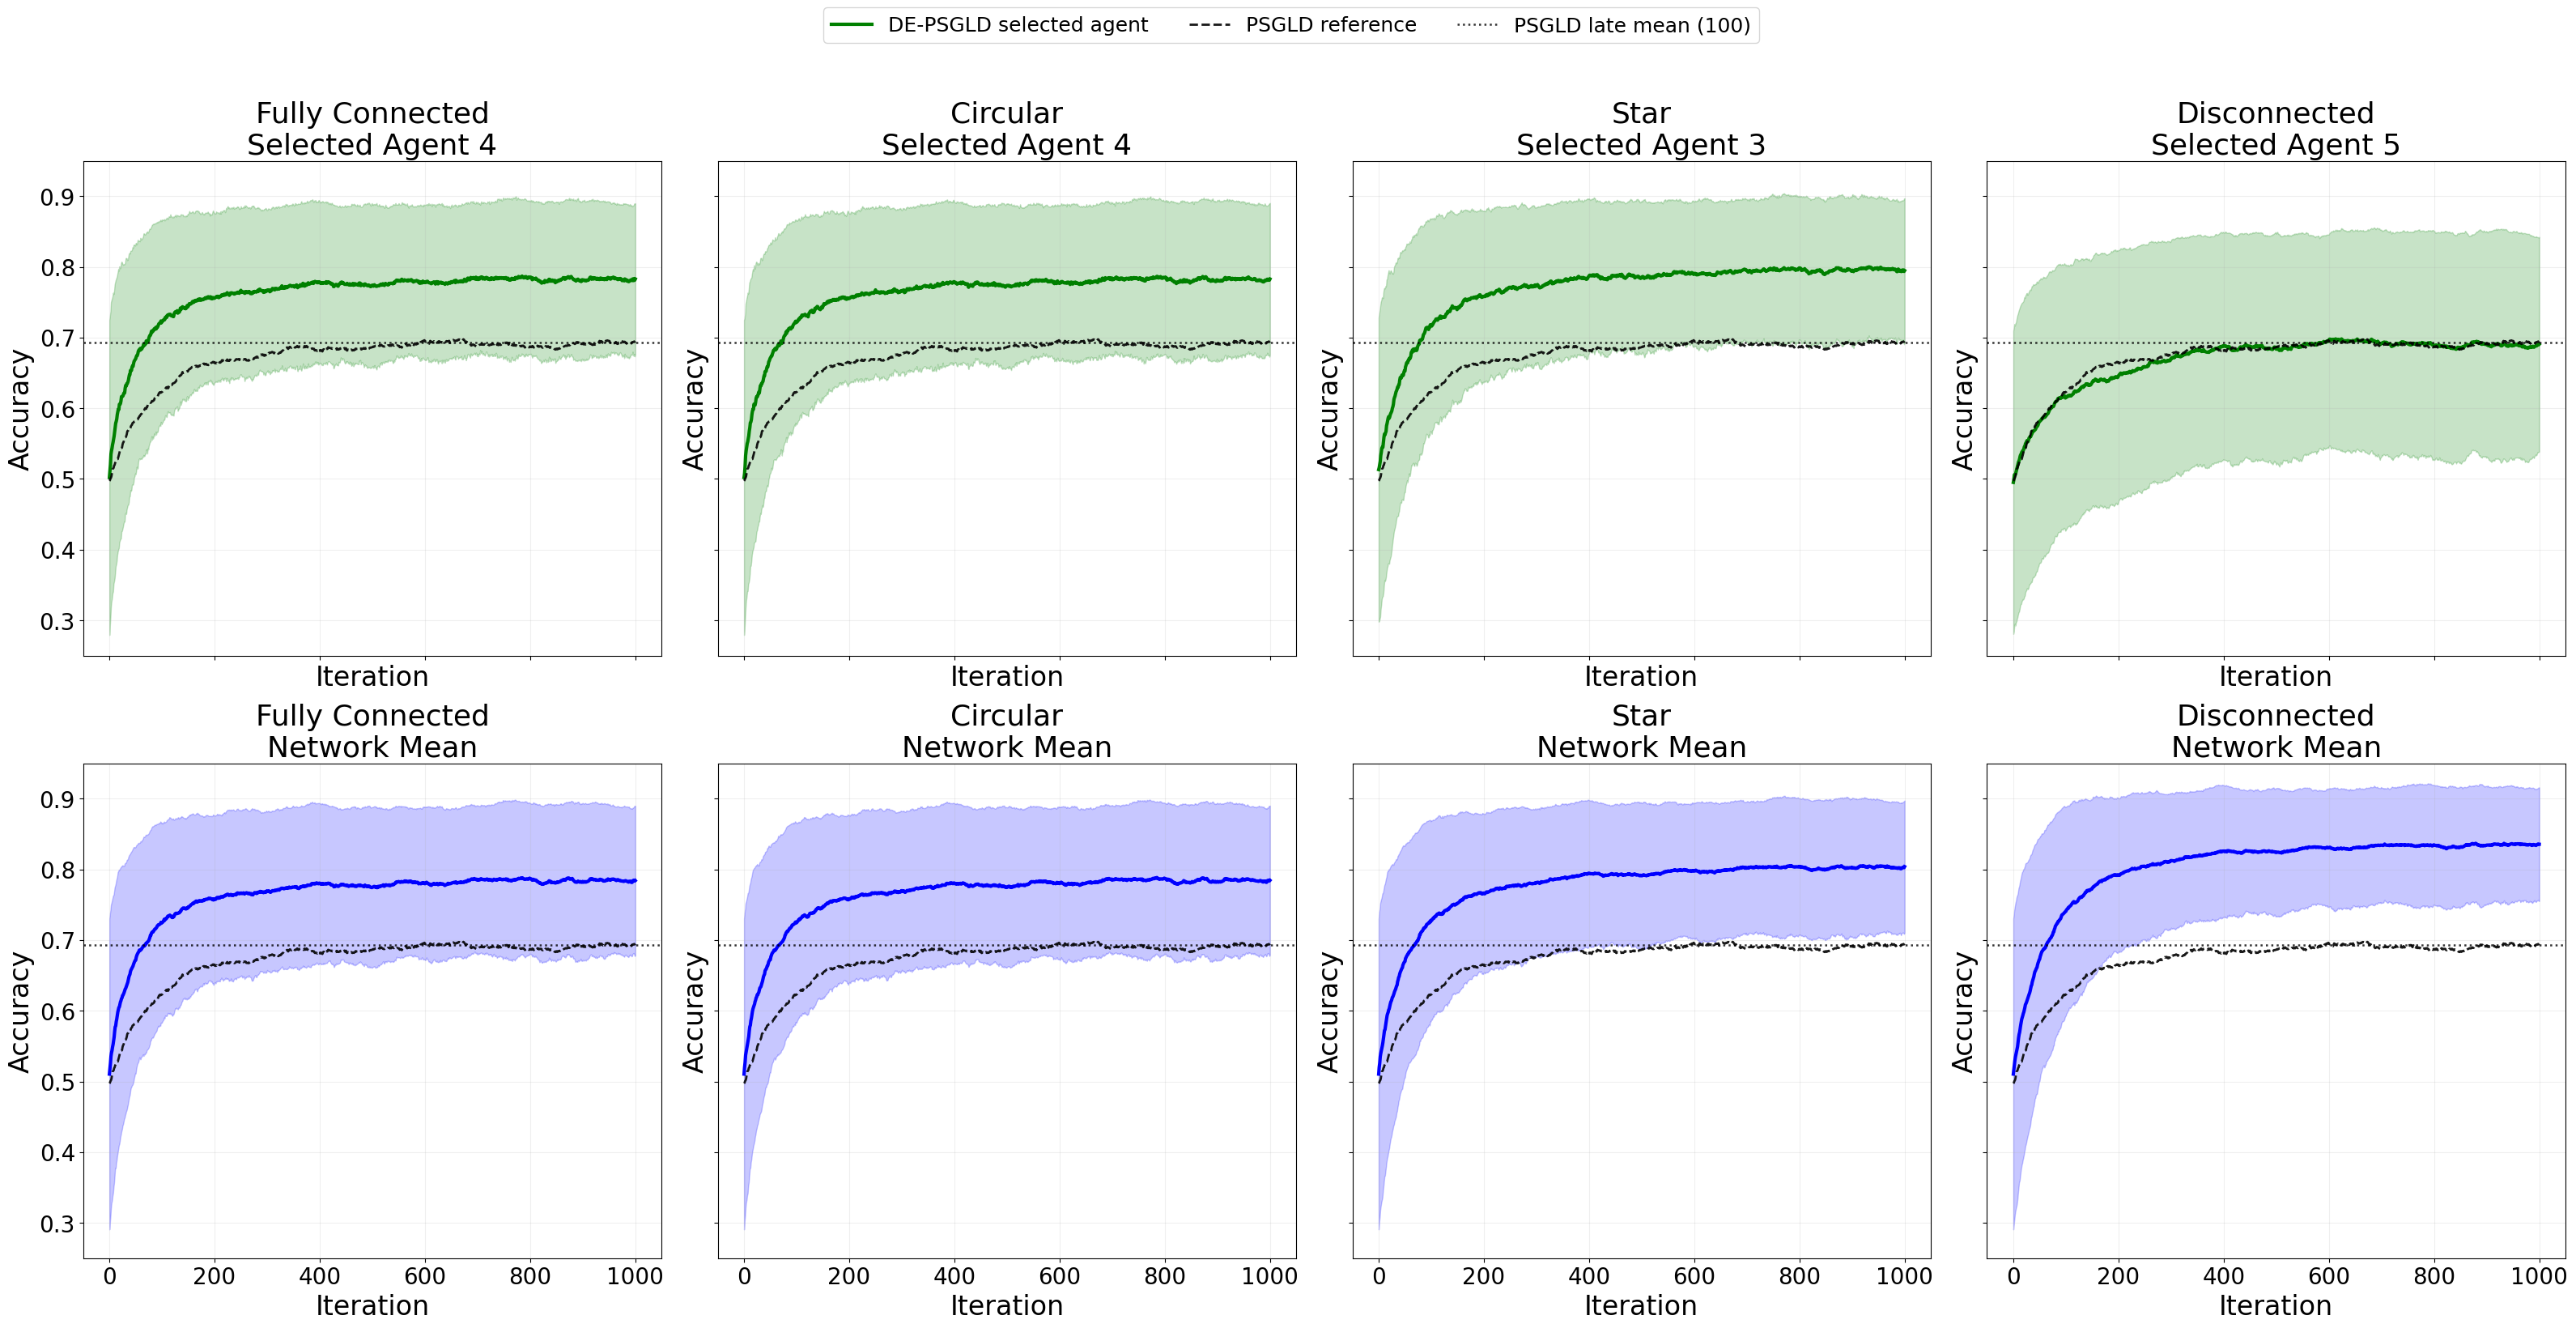


Late-stage summary over last 100 iterations:

Fully Connected    | Agent  4 mean: 0.7827 (std 0.0015) | Network mean: 0.7845 (std 0.0013) | MYSGLD ref: 0.6926 (std 0.0017)
Circular           | Agent  4 mean: 0.7824 (std 0.0015) | Network mean: 0.7846 (std 0.0013) | MYSGLD ref: 0.6926 (std 0.0017)
Star               | Agent  3 mean: 0.7969 (std 0.0016) | Network mean: 0.8033 (std 0.0011) | MYSGLD ref: 0.6926 (std 0.0017)
Disconnected       | Agent  5 mean: 0.6887 (std 0.0015) | Network mean: 0.8353 (std 0.0007) | MYSGLD ref: 0.6926 (std 0.0017)


In [7]:
run_sampling(n_samples=1000, n_iters=1000, eta=5e-3, gamma=0.16)